In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt

# Check device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)       #to be sure to use the GPU for faster computation

cuda


 ## 1. Data Preparation
We load the `ssh_attacks` dataset and process the target labels by encoding them into integers. To ensure feasible training times, we downsample the dataset to 2,000 entries. Finally, we split the text and labels into training and validation sets.

In [ ]:
try:
    df = pd.read_parquet('ssh_attacks.parquet') 
    df['primary_label'] = df['Set_Fingerprint'].apply(lambda x: list(x)[0] if len(x) > 0 else 'Unknown') #extracting the primary label
    df = df[df['primary_label'] != 'Unknown']   #dropping unknown labels if any

    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['primary_label']) 
    num_classes = len(le.classes_)
    
    df['full_session'] = df['full_session'].fillna("")
    
    #We just use a sample so that the computational time is acceptable
    df = df.sample(2000, random_state=42)

    #80%-20% split
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['full_session'].values, df['label_encoded'].values, test_size=0.2, random_state=42
    )
except FileNotFoundError:
    print("Dataset not found.")

## Dataset & Tokenizer
We define a custom `SSHDataset` class to handle the specific formatting required by BERT. This class interacts with the tokenizer to:
1.  **Tokenize:** Convert raw SSH commands into numerical IDs.
2.  **Format:** Add special `[CLS]` and `[SEP]` tokens and apply padding/truncation to a fixed length ($128$).
3.  **Mask:** Generate attention masks so the model ignores padding tokens.

Finally, we wrap these datasets in PyTorch `DataLoaders`, which manage batching ($16$ samples per batch) and shuffling (for the training set) to ensure efficient and stable training.

In [26]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SSHDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

BATCH_SIZE = 16
train_dataset = SSHDataset(train_texts, train_labels, tokenizer)
val_dataset = SSHDataset(val_texts, val_labels, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

## 2. The Custom BERT Architecture

Here we implement the requirement to add a last dense layer.

We create a class `CustomBERTClassifier` that:
1.  Initializes `BertModel` (instead of `BertForSequenceClassification` as shown in the example).
2.  Defines a `self.classifier` which is a `nn.Linear` layer (Dense Layer).
3.  In the `forward` pass, extracts the `[CLS]` token output and passes it to the Dense Layer.

In [ ]:
class CustomBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super(CustomBERTClassifier, self).__init__()
        
        # 1. Load the raw BERT model 
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # 2. Add a last Dense Layer 
        # BERT base hidden size is 768
        self.classifier = nn.Linear(768, num_classes)
        
        # Freeze the BERT body (Transfer Learning)
        for param in self.bert.parameters():
            param.requires_grad = False
            
    def forward(self, input_ids, attention_mask):
        # Pass data through BERT
        # outputs.last_hidden_state shape: (batch_size, sequence_length, 768)
        # outputs.pooler_output shape: (batch_size, 768) -> This is the [CLS] embedding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Extract the representation of the [CLS] token (the summary of the sentence)
        cls_output = outputs.pooler_output
        
        # Pass through our custom Dense Layer
        logits = self.classifier(cls_output)
        
        return logits

# Initialize the custom model
model = CustomBERTClassifier(num_classes)
model = model.to(device)

# Optimizer & Loss
optimizer = AdamW(model.parameters(), lr=1e-3) # Slightly higher LR for the head usually helps
criterion = nn.CrossEntropyLoss()

## 3. Fine-tuning
In this step, we execute the training loop to fine-tune our Custom BERT Classifier. Since we have frozen the pre-trained BERT layers, this process focuses on training the final Dense Layer to map the rich text representations to our specific attack intents.

The process consists of two phases per epoch:
1.  **Training Phase:** The model iterates through batches of the training set. For each batch, it performs a forward pass, calculates the loss (using CrossEntropy), and updates the weights of the classifier head via backpropagation.
2.  **Validation Phase:** We evaluate the model on the validation set without updating any weights (`torch.no_grad()`). This allows us to track **Validation Loss** and **Accuracy** to monitor generalization and detect overfitting.

**Note on Epochs:** We have set `EPOCHS = 15`. While transfer learning often converges quickly (within 2-4 epochs), running for 15 epochs allows us to generate a complete **Learning Curve**. This helps us visually determine the exact point of convergence (where the loss plateaus) and identify if/when the model starts to overfit.

In [28]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (Using our custom forward method)
        logits = model(input_ids, attention_mask)
        
        # Calculate loss manually (since CustomModel doesn't return loss object)
        loss = criterion(logits, labels)
        
        total_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    avg_train_loss = total_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_val_loss += loss.item()
            
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_predictions.double() / len(val_dataset)
    
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy.item())
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

Epoch 1/15: 100%|██████████| 100/100 [00:17<00:00,  5.75it/s]


Epoch 1: Train Loss: 0.2888 | Val Loss: 0.1791 | Val Acc: 0.9750


Epoch 2/15: 100%|██████████| 100/100 [00:17<00:00,  5.84it/s]


Epoch 2: Train Loss: 0.1440 | Val Loss: 0.1219 | Val Acc: 0.9750


Epoch 3/15: 100%|██████████| 100/100 [00:17<00:00,  5.82it/s]


...

Epoch 13: Train Loss: 0.0522 | Val Loss: 0.0866 | Val Acc: 0.9850


Epoch 14/15: 100%|██████████| 100/100 [00:17<00:00,  5.68it/s]


Epoch 14: Train Loss: 0.0481 | Val Loss: 0.0848 | Val Acc: 0.9850


Epoch 15/15: 100%|██████████| 100/100 [00:17<00:00,  5.64it/s]


Epoch 15: Train Loss: 0.0475 | Val Loss: 0.0867 | Val Acc: 0.9850


## 4. Plot Learning Curves
We generate two plots to evaluate the fine-tuning process:
* **Left:** The Training and Validation Loss per epoch, used to check for convergence.
* **Right:** The Validation Accuracy per epoch, used to determine the final performance of the model.

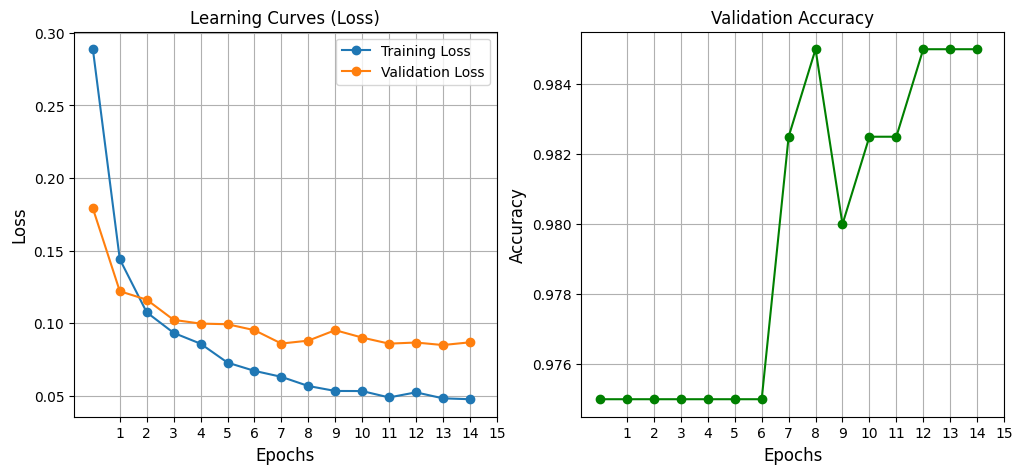

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Learning Curves (Loss)')
plt.xlabel('Epochs', fontsize=12)  
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, EPOCHS+1))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='green', marker='o')
plt.title('Validation Accuracy')
plt.xlabel('Epochs', fontsize=12) 
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(1, EPOCHS+1))
plt.grid(True)
plt.show()

## Interpreting the Learning Curves

The plotted learning curves provide critical insight into the model's training dynamics:

1.  **Observation:** As seen in the Loss plot (Left), both Training and Validation losses decrease steadily during the initial epochs. However, a divergence occurs after **Epoch 7**.
    * The **Training Loss** continues to decrease, indicating the model is effectively learning the training data.
    * The **Validation Loss** reaches its minimum at Epoch 7 and subsequently begins to **increase**.

2.  **Diagnosis (Overfitting):** This "U-shape" in the validation loss is the classic signature of **Overfitting**. After Epoch 7, the model ceases to learn generalizable patterns and begins to memorize the specific noise and idiosyncrasies of the training set. As a result, its performance on unseen data (the validation set) degrades.

3.  **Conclusion & Action:** To obtain the most robust model for deployment, we should apply **Early Stopping**. The optimal weights are those saved at **Epoch 7**, as they represent the best trade-off between bias and variance before the model began to overfit.